<a href="https://colab.research.google.com/github/sefaul-islam/Benford-Curse/blob/main/RegressionLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sohier/calcofi")

print("Path to dataset files:", path)

KeyboardInterrupt: 

In [15]:
csv_file_path = os.path.join(path, "bottle.csv")
print(csv_file_path)
df =pd.read_csv(csv_file_path, low_memory=False)
# 3. Clean and isolate the features
# Drop rows that are missing temperature or salinity data
df_clean = df[['Salnty', 'T_degC']].dropna()
# Randomly sample 1,000 rows.
# (Plotting the entire 800,000+ row dataset is slow and creates a visually messy graph)
df_sample = df_clean.sample(n=1000, random_state=42)


/root/.cache/kagglehub/datasets/sohier/calcofi/versions/2/bottle.csv


        Salnty
117048  33.390
127000  32.670
19609   34.020
184292  34.335
747283  34.226
...        ...
15079   34.400
553378  33.804
601053  32.808
751211  34.043
203571  34.549

[1000 rows x 1 columns]


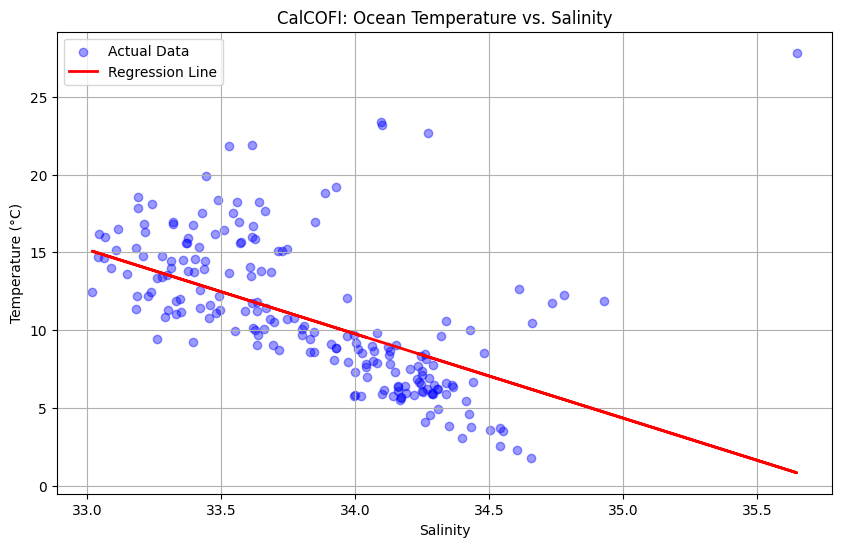

In [16]:
# Define X (features - must be 2D) and y (target - 1D)
X = df_sample[['Salnty']]
y = df_sample['T_degC']
print(X)
# 4. Split the data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# 5. Train the Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 6. Predict temperatures for the test set
y_pred = model.predict(X_test)

# 7. Visualize with Matplotlib
plt.figure(figsize=(10, 6))

# Plot the actual test data points
plt.scatter(X_test, y_test, color='blue', alpha=0.4, label='Actual Data')

# Plot the regression line generated by the model
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')

# Formatting
plt.title('CalCOFI: Ocean Temperature vs. Salinity')
plt.xlabel('Salinity')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)

# Render the plot
plt.show()

In [14]:
from sklearn.metrics import mean_squared_error, r2_score

# Calculate the evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the results
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R²): {r2:.4f}")

Mean Squared Error (MSE): 15.6286
R-squared (R²): 0.2821
